## Modeling — Residual CNN

**Purpose:** We build one clean compact residual CNN from scratch, tune it on the strict modeling manifest, and inspect the selected model using the same evaluation discipline as the earlier baselines.

**Notebook Rules**
- We keep logic inside `src/`.
- We use the strict modeling manifest only.
- We select the final CNN setup using **validation macro F1**.
- We keep one overwrite-only final artifact set for this model.

In [1]:
# We set up the project path, import the shared config and utilities, and print the main project summary.

from pathlib import Path
import sys

currentDir = Path.cwd().resolve()
projectRoot = currentDir.parent if currentDir.name == "notebooks" else currentDir

if str(projectRoot) not in sys.path:
    sys.path.append(str(projectRoot))

from src.config import projectConfig
from src.utils import ensureProjectDirs, printProjectSummary, setGlobalSeed, applyPlotStyle

setGlobalSeed(projectConfig.seed)
ensureProjectDirs(projectConfig)
applyPlotStyle()
printProjectSummary(projectConfig)

projectRoot: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis
seed: 27
device: mps
imageDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/JPEGImages
annotationDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/Annotations
splitFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/train_val_test_split.txt
classFilePath: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataRaw/wtDataset/class_definitions.txt
cropsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/dataProcessed/crops
metricsDir: /Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/metrics


### Strict Modeling Manifest

We rebuild the strict modeling manifest first so the residual CNN uses the same leakage-safe input as the earlier models.

In [2]:
# We build the strict modeling manifest and inspect the saved summary before CNN tuning.

import json

from src.data import runModelingManifestBuilder

modelingManifestResult = runModelingManifestBuilder(projectConfig)
modelingManifestSummaryPath = modelingManifestResult["savedPathDict"]["modelingManifestSummaryStrict"]

with open(modelingManifestSummaryPath, "r", encoding="utf-8") as fileObject:
    modelingManifestSummary = json.load(fileObject)

modelingManifestSummary

{'rawCropCount': 1584,
 'strictModelingCropCount': 1580,
 'excludedDuplicateCropCount': 4,
 'excludedCrossSplitDuplicateCropCount': 2,
 'strictUniqueSourceImageCount': 1061,
 'strictTrainCropCount': 1097,
 'strictValCropCount': 245,
 'strictTestCropCount': 238}

### Residual CNN Setup

We define one clean default residual CNN setup first so the tuning cell later starts from a sensible and explainable baseline.

In [3]:
# We import the residual CNN helpers and build the default model and training configs.

from src.models import (
    ResidualCnnClassifier,
    ResidualCnnTrialSpec,
    buildDefaultResidualCnnConfig,
    buildDefaultResidualCnnTrainingConfig,
    buildDefaultResidualCnnTrialSpec,
)

cnnConfig = buildDefaultResidualCnnConfig(projectConfig)
cnnTrainingConfig = buildDefaultResidualCnnTrainingConfig(projectConfig)
cnnDefaultTrialSpec = buildDefaultResidualCnnTrialSpec(projectConfig)

cnnConfig, cnnTrainingConfig, cnnDefaultTrialSpec

(ResidualCnnConfig(inputChannels=3, numClasses=6, baseChannels=32, stageBlockCounts=(2, 2, 2, 2), dropoutRate=0.2, useBatchNorm=True),
 ResidualCnnTrainingConfig(imageSize=160, batchSize=32, learningRate=0.0003, weightDecay=0.0001, numEpochs=80, earlyStoppingPatience=15, labelSmoothing=0.0, useClassWeights=True, randomSeed=27),
 ResidualCnnTrialSpec(trialName='residualCnnDefault', imageSize=160, batchSize=32, learningRate=0.0003, weightDecay=0.0001, numEpochs=80, earlyStoppingPatience=15, labelSmoothing=0.0, useClassWeights=True, baseChannels=32, stageBlockCounts=(2, 2, 2, 2), dropoutRate=0.2, useBatchNorm=True, randomSeed=27))

### Residual CNN Tuning Plan

We start with a clean first residual CNN search that varies only the most meaningful settings: model width, depth pattern, dropout, learning rate, weight decay, image size, and batch size.

In [4]:
# We run one final winner-side residual CNN search around the strongest proven 192px family.

from dataclasses import replace
import pandas as pd

baseTrialSpec = ResidualCnnTrialSpec(
    trialName="cnn_img192_anchor",
    imageSize=192,
    batchSize=24,
    learningRate=3e-4,
    weightDecay=1e-4,
    numEpochs=130,
    earlyStoppingPatience=26,
    labelSmoothing=0.0,
    useClassWeights=True,
    baseChannels=32,
    stageBlockCounts=(2, 2, 2, 2),
    dropoutRate=0.20,
    useBatchNorm=True,
    randomSeed=projectConfig.seed,
)

cnnTrialSpecList = [
    # We keep the exact current best so overwrite-safe final artifacts remain valid if nothing beats it.
    baseTrialSpec,

    # We test slightly stronger regularization around the winner.
    replace(
        baseTrialSpec,
        trialName="cnn_img192_anchor_wd2e4",
        weightDecay=2e-4,
    ),
    replace(
        baseTrialSpec,
        trialName="cnn_img192_anchor_wd3e4",
        weightDecay=3e-4,
    ),

    # We test whether slightly lighter dropout helps at 192px.
    replace(
        baseTrialSpec,
        trialName="cnn_img192_anchor_do010",
        dropoutRate=0.10,
    ),
    replace(
        baseTrialSpec,
        trialName="cnn_img192_anchor_do015",
        dropoutRate=0.15,
    ),

    # We test slightly slower optimization around the winner.
    replace(
        baseTrialSpec,
        trialName="cnn_img192_anchor_lr2e4",
        learningRate=2e-4,
    ),
    replace(
        baseTrialSpec,
        trialName="cnn_img192_anchor_lr25e4",
        learningRate=2.5e-4,
    ),

    # We test whether a smaller batch improves generalization for the same winner family.
    replace(
        baseTrialSpec,
        trialName="cnn_img192_anchor_bs16_lr2e4",
        batchSize=16,
        learningRate=2e-4,
    ),

    # We test one slightly larger image scale because 192 beat 160 and 224, so 208 is a sensible final check.
    replace(
        baseTrialSpec,
        trialName="cnn_img208_anchor_bs16",
        imageSize=208,
        batchSize=16,
    ),
    replace(
        baseTrialSpec,
        trialName="cnn_img208_anchor_bs16_wd2e4",
        imageSize=208,
        batchSize=16,
        weightDecay=2e-4,
    ),

    # We test one middle-width family because 32 won and 48 was strong, so 40 is the best untested width.
    replace(
        baseTrialSpec,
        trialName="cnn_img192_mid40_bs20",
        baseChannels=40,
        batchSize=20,
    ),
    replace(
        baseTrialSpec,
        trialName="cnn_img192_mid40_bs20_wd2e4",
        baseChannels=40,
        batchSize=20,
        weightDecay=2e-4,
    ),
]

cnnTrialPlanDf = pd.DataFrame(
    [
        {
            "trialName": trialSpec.trialName,
            "imageSize": trialSpec.imageSize,
            "batchSize": trialSpec.batchSize,
            "learningRate": trialSpec.learningRate,
            "weightDecay": trialSpec.weightDecay,
            "numEpochs": trialSpec.numEpochs,
            "earlyStoppingPatience": trialSpec.earlyStoppingPatience,
            "labelSmoothing": trialSpec.labelSmoothing,
            "useClassWeights": trialSpec.useClassWeights,
            "baseChannels": trialSpec.baseChannels,
            "stageBlockCounts": str(trialSpec.stageBlockCounts),
            "dropoutRate": trialSpec.dropoutRate,
            "useBatchNorm": trialSpec.useBatchNorm,
        }
        for trialSpec in cnnTrialSpecList
    ]
)

print(f"Number of planned trials: {len(cnnTrialSpecList)}")
cnnTrialPlanDf

Number of planned trials: 12


,trialName,imageSize,batchSize,learningRate,weightDecay,numEpochs,earlyStoppingPatience,labelSmoothing,useClassWeights,baseChannels,stageBlockCounts,dropoutRate,useBatchNorm
0,cnn_img192_anchor,192,24,0.00030,0.0001,130,26,0.0,True,32,"(2, 2, 2, 2)",0.20,True
1,cnn_img192_anchor_wd2e4,192,24,0.00030,0.0002,130,26,0.0,True,32,"(2, 2, 2, 2)",0.20,True
2,cnn_img192_anchor_wd3e4,192,24,0.00030,0.0003,130,26,0.0,True,32,"(2, 2, 2, 2)",0.20,True
3,cnn_img192_anchor_do010,192,24,0.00030,0.0001,130,26,0.0,True,32,"(2, 2, 2, 2)",0.10,True
4,cnn_img192_anchor_do015,192,24,0.00030,0.0001,130,26,0.0,True,32,"(2, 2, 2, 2)",0.15,True
5,cnn_img192_anchor_lr2e4,192,24,0.00020,0.0001,130,26,0.0,True,32,"(2, 2, 2, 2)",0.20,True
6,cnn_img192_anchor_lr25e4,192,24,0.00025,0.0001,130,26,0.0,True,32,"(2, 2, 2, 2)",0.20,True
7,cnn_img192_anchor_bs16_lr2e4,192,16,0.00020,0.0001,130,26,0.0,True,32,"(2, 2, 2, 2)",0.20,True
8,cnn_img208_anchor_bs16,208,16,0.00030,0.0001,130,26,0.0,True,32,"(2, 2, 2, 2)",0.20,True
9,cnn_img208_anchor_bs16_wd2e4,208,16,0.00030,0.0002,130,26,0.0,True,32,"(2, 2, 2, 2)",0.20,True


### Residual CNN Search

We run the notebook-defined residual CNN search, keep only the best validation model as the saved source of truth, and overwrite the previous CNN artifacts.

In [5]:
# We run the residual CNN hyperparameter search and keep only the best validation model artifacts.

from src.models import runResidualCnnHyperparameterSearch

cnnResult = runResidualCnnHyperparameterSearch(
    projectConfig=projectConfig,
    trialSpecList=cnnTrialSpecList,
    verbose=True,
)

cnnResult["artifactPathDict"]

[search] trialStart | index=1/12 | name=cnn_img192_anchor
[cnn_img192_anchor] start | cnn(baseChannels=32, stageBlockCounts=(2, 2, 2, 2), dropoutRate=0.2, useBatchNorm=True) | opt(imageSize=192, batchSize=24, learningRate=0.0003, weightDecay=0.0001, labelSmoothing=0.0, useClassWeights=True)
[cnn_img192_anchor] epoch=001/130 | lr=0.000300 | trainLoss=1.7591 | valLoss=1.6543 | trainMacroF1=0.2584 | valMacroF1=0.2691 | bestValMacroF1=0.2691
[cnn_img192_anchor] epoch=002/130 | lr=0.000300 | trainLoss=1.6179 | valLoss=1.6350 | trainMacroF1=0.3275 | valMacroF1=0.2805 | bestValMacroF1=0.2805
[cnn_img192_anchor] epoch=003/130 | lr=0.000300 | trainLoss=1.5659 | valLoss=1.5493 | trainMacroF1=0.3628 | valMacroF1=0.3013 | bestValMacroF1=0.3013
[cnn_img192_anchor] epoch=004/130 | lr=0.000300 | trainLoss=1.5584 | valLoss=1.6043 | trainMacroF1=0.3691 | valMacroF1=0.3207 | bestValMacroF1=0.3207
[cnn_img192_anchor] epoch=005/130 | lr=0.000300 | trainLoss=1.4690 | valLoss=1.4838 | trainMacroF1=0.4023 | 

{'modelPath': PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/models/residualCnn/residualCnnClassifier.pt'),
 'cnnConfigPath': PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/tables/residualCnn/residualCnnConfig.json'),
 'trainingConfigPath': PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/tables/residualCnn/residualCnnTrainingConfig.json'),
 'tuningSummaryPath': PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/tables/residualCnn/residualCnnTuningSummary.csv'),
 'historyPath': PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/metrics/residualCnn/residualCnnTrainingHistory.csv'),
 'metricSummaryPath': PosixPath('/Users/princebhanusteta/Documents/Projects/MajorProject_ML/WTDAnalysis/outputs/metrics/residualCnn/residualCnnMetricSummary.csv'),
 'valPredictionsPath': PosixPath('/Users/pr

In [6]:
# We inspect the top 5 CNN trials from the saved tuning summary.

import pandas as pd

cnnTuningSummaryDf = pd.read_csv(cnnResult["artifactPathDict"]["tuningSummaryPath"])

cnnTuningSummaryDf.sort_values(
    by=["valMacroF1", "testMacroF1", "valAccuracy"],
    ascending=False,
).head(5)

,trialName,imageSize,batchSize,learningRate,weightDecay,numEpochs,earlyStoppingPatience,labelSmoothing,useClassWeights,baseChannels,stageBlockCounts,dropoutRate,useBatchNorm,bestEpoch,trainAccuracy,valAccuracy,testAccuracy,trainMacroF1,valMacroF1,testMacroF1
0,cnn_img192_anchor_wd2e4,192,24,0.00030,0.0002,130,26,0.0,True,32,"(2, 2, 2, 2)",0.2,True,116,0.969006,0.861224,0.861345,0.972750,0.836612,0.855983
1,cnn_img192_anchor,192,24,0.00030,0.0001,130,26,0.0,True,32,"(2, 2, 2, 2)",0.2,True,78,0.965360,0.865306,0.857143,0.969257,0.835922,0.854657
2,cnn_img192_anchor_lr2e4,192,24,0.00020,0.0001,130,26,0.0,True,32,"(2, 2, 2, 2)",0.2,True,75,0.973564,0.853061,0.840336,0.976289,0.830465,0.844698
3,cnn_img192_anchor_lr25e4,192,24,0.00025,0.0001,130,26,0.0,True,32,"(2, 2, 2, 2)",0.2,True,91,0.960802,0.840816,0.840336,0.962743,0.818914,0.841718
4,cnn_img192_anchor_wd3e4,192,24,0.00030,0.0003,130,26,0.0,True,32,"(2, 2, 2, 2)",0.2,True,78,0.965360,0.832653,0.827731,0.967193,0.810395,0.826435


In [7]:
# We show only the single best validation CNN config.

bestCnnConfigDf = (
    cnnTuningSummaryDf
    .sort_values(by=["valMacroF1", "testMacroF1", "valAccuracy"], ascending=False)
    .head(1)[[
        "trialName",
        "imageSize",
        "batchSize",
        "learningRate",
        "weightDecay",
        "numEpochs",
        "earlyStoppingPatience",
        "labelSmoothing",
        "useClassWeights",
        "baseChannels",
        "stageBlockCounts",
        "dropoutRate",
        "useBatchNorm",
        "bestEpoch",
        "valMacroF1",
    ]]
    .reset_index(drop=True)
)

bestCnnConfigDf

,trialName,imageSize,batchSize,learningRate,weightDecay,numEpochs,earlyStoppingPatience,labelSmoothing,useClassWeights,baseChannels,stageBlockCounts,dropoutRate,useBatchNorm,bestEpoch,valMacroF1
0,cnn_img192_anchor_wd2e4,192,24,0.0003,0.0002,130,26,0.0,True,32,"(2, 2, 2, 2)",0.2,True,116,0.836612


In [8]:
# We show the final train, validation, and test metrics for the selected best CNN run.

cnnMetricSummaryDf = pd.read_csv(cnnResult["artifactPathDict"]["metricSummaryPath"])

cnnFinalMetricsDf = (
    cnnMetricSummaryDf[[
        "split",
        "accuracy",
        "macroPrecision",
        "macroRecall",
        "macroF1",
        "weightedF1",
    ]]
    .copy()
    .round(4)
)

cnnFinalMetricsDf

,split,accuracy,macroPrecision,macroRecall,macroF1,weightedF1
0,train,0.9690,0.9712,0.9748,0.9727,0.9690
1,val,0.8612,0.8310,0.8437,0.8366,0.8622
2,test,0.8613,0.8477,0.8697,0.8560,0.8622


### Residual CNN Training Curves

We inspect the saved training history of the selected residual CNN and mark the best epoch chosen by validation macro F1.

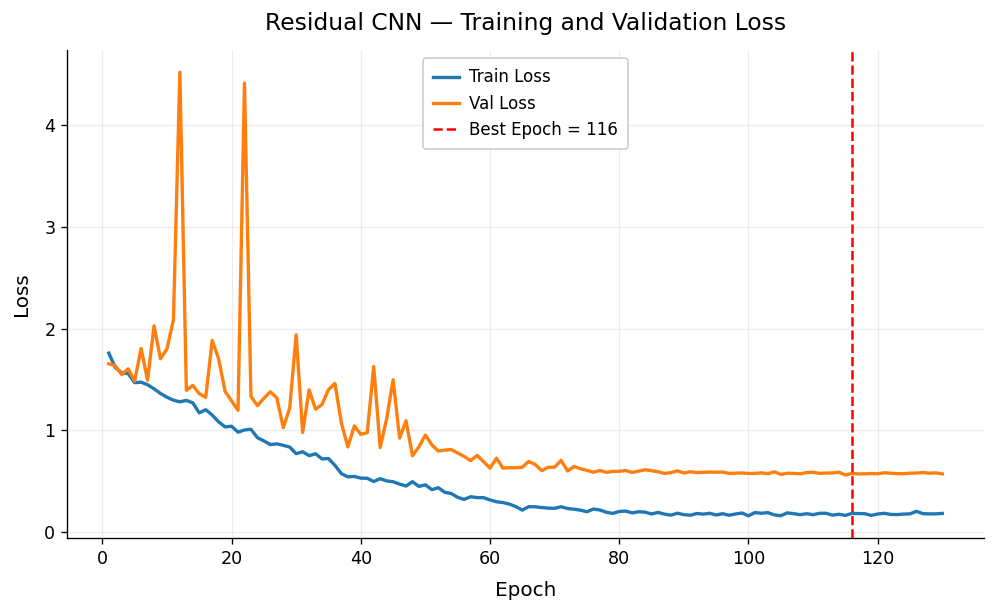

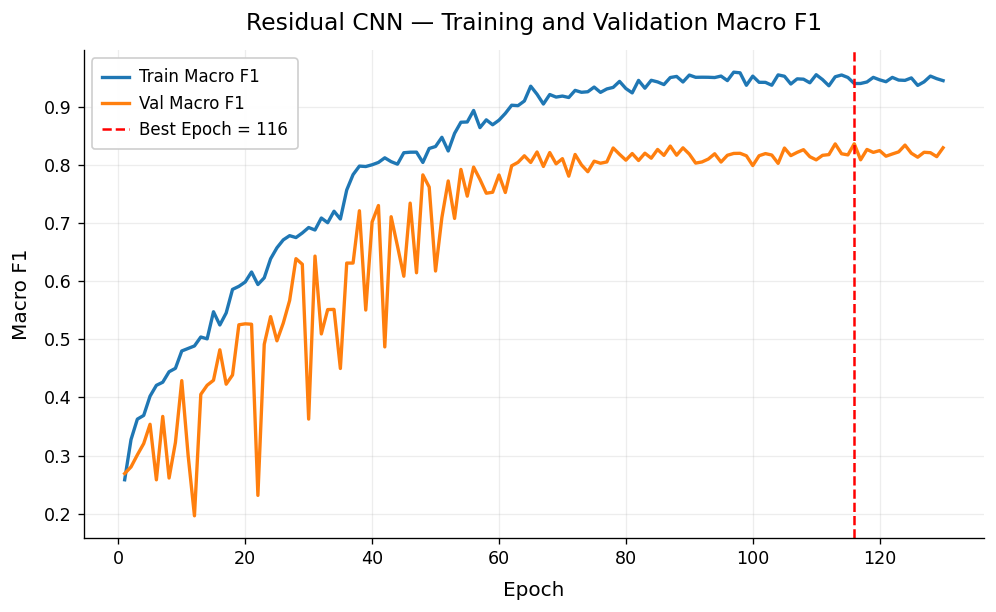

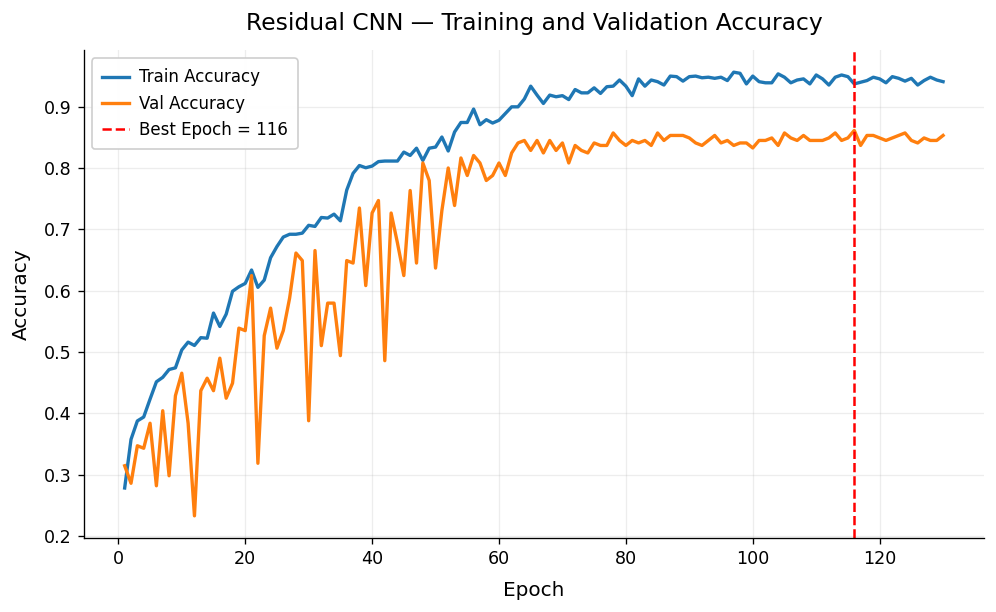

['residualCnnTrainingValidationAccuracy.png',
 'residualCnnTrainingValidationLoss.png',
 'residualCnnTrainingValidationMacroF1.png']

In [15]:
# We recreate and save the CNN training curves directly from the saved history.

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

cnnFigureDir = projectConfig.figuresDir / "residualCnn"
cnnFigureDir.mkdir(parents=True, exist_ok=True)

cnnTuningSummaryDf = pd.read_csv(cnnResult["artifactPathDict"]["tuningSummaryPath"])
cnnHistoryDf = pd.read_csv(cnnResult["artifactPathDict"]["historyPath"])

bestEpoch = int(
    cnnTuningSummaryDf.sort_values(
        by=["valMacroF1", "testMacroF1", "valAccuracy"],
        ascending=False,
    ).iloc[0]["bestEpoch"]
)

figureObject = plt.figure(figsize=(8.4, 5.2))
plt.plot(cnnHistoryDf["epoch"], cnnHistoryDf["trainLoss"], label="Train Loss")
plt.plot(cnnHistoryDf["epoch"], cnnHistoryDf["valLoss"], label="Val Loss")
plt.axvline(bestEpoch, linestyle="--", linewidth=1.5, color="red", label=f"Best Epoch = {bestEpoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Residual CNN — Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(cnnFigureDir / "residualCnnTrainingValidationLoss.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()

figureObject = plt.figure(figsize=(8.4, 5.2))
plt.plot(cnnHistoryDf["epoch"], cnnHistoryDf["trainMacroF1"], label="Train Macro F1")
plt.plot(cnnHistoryDf["epoch"], cnnHistoryDf["valMacroF1"], label="Val Macro F1")
plt.axvline(bestEpoch, linestyle="--", linewidth=1.5, color="red", label=f"Best Epoch = {bestEpoch}")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Residual CNN — Training and Validation Macro F1")
plt.legend()
plt.tight_layout()
plt.savefig(cnnFigureDir / "residualCnnTrainingValidationMacroF1.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()

figureObject = plt.figure(figsize=(8.4, 5.2))
plt.plot(cnnHistoryDf["epoch"], cnnHistoryDf["trainAccuracy"], label="Train Accuracy")
plt.plot(cnnHistoryDf["epoch"], cnnHistoryDf["valAccuracy"], label="Val Accuracy")
plt.axvline(bestEpoch, linestyle="--", linewidth=1.5, color="red", label=f"Best Epoch = {bestEpoch}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Residual CNN — Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(cnnFigureDir / "residualCnnTrainingValidationAccuracy.png", dpi=220, bbox_inches="tight")
plt.show()
plt.close()

sorted(path.name for path in cnnFigureDir.glob("residualCnnTrainingValidation*.png"))

### Interpretation of the Residual CNN Training Curves

The residual CNN learns the task steadily over a long training horizon. Training loss decreases consistently, while validation loss is noisy in the early and middle epochs and then stabilizes much later. At the same time, both validation macro-F1 and validation accuracy rise clearly and only flatten near the end of training. This is why the selected best epoch appears late: the CNN needs more epochs than the HOG + MLP model before its validation performance fully settles.

The gap between train and validation curves shows **moderate overfitting**, but it is controlled rather than harmful. Training continues to improve beyond the point where validation gains become smaller, so the final checkpoint is selected by **validation macro-F1** instead of by the final epoch or lowest loss. Overall, the curves support the conclusion that the residual CNN is learning meaningful spatial features from raw crops and generalizes better than the earlier HOG-based models.

### Residual CNN Confusion Matrices

We inspect the saved validation and test predictions of the selected residual CNN using the same blue-correct and red-error confusion-matrix style as the MLP.

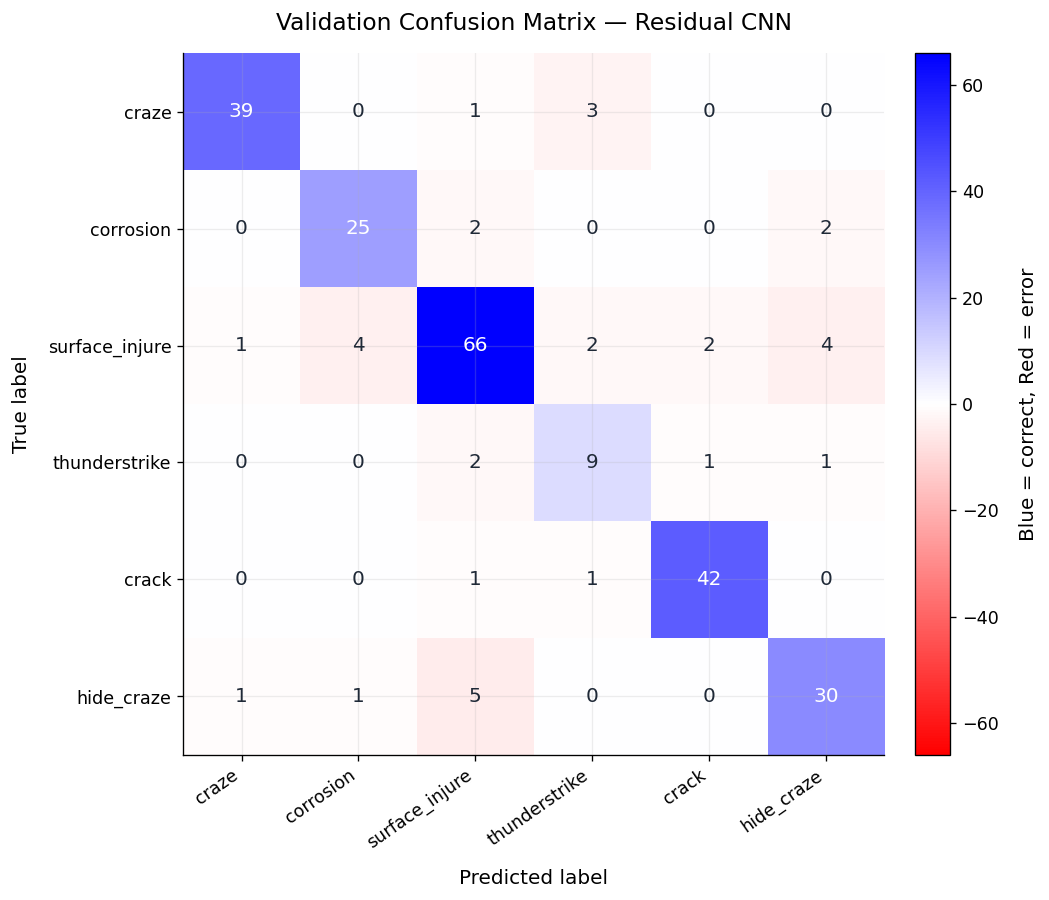

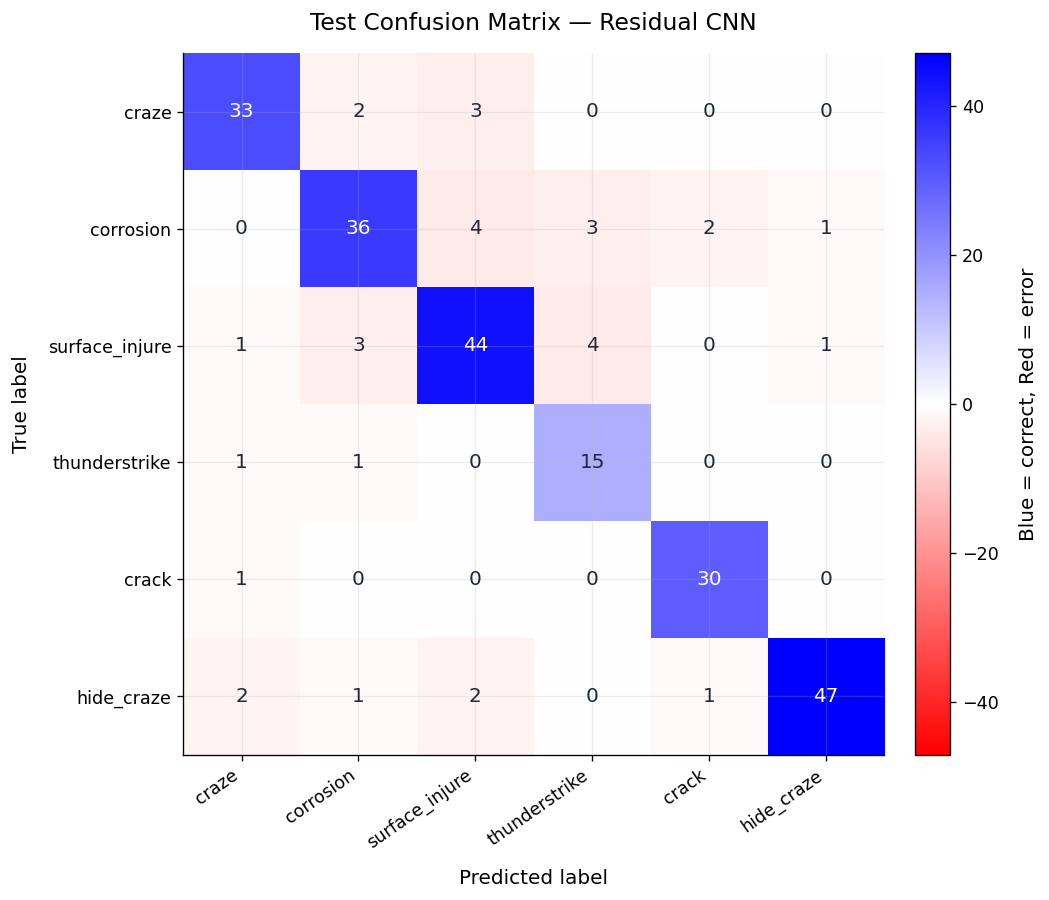

['residualCnnTestConfusionMatrix.png',
 'residualCnnValidationConfusionMatrix.png']

In [16]:
# We recreate and save the CNN confusion matrices directly from the saved prediction files.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cnnFigureDir = projectConfig.figuresDir / "residualCnn"
cnnFigureDir.mkdir(parents=True, exist_ok=True)

cnnValPredictionDf = pd.read_csv(cnnResult["artifactPathDict"]["valPredictionsPath"])
cnnTestPredictionDf = pd.read_csv(cnnResult["artifactPathDict"]["testPredictionsPath"])

valConfusionMatrix = confusion_matrix(
    cnnValPredictionDf["trueClassName"],
    cnnValPredictionDf["predictedClassName"],
    labels=projectConfig.classNames,
)

testConfusionMatrix = confusion_matrix(
    cnnTestPredictionDf["trueClassName"],
    cnnTestPredictionDf["predictedClassName"],
    labels=projectConfig.classNames,
)

def buildSignedConfusionMatrix(confusionMatrix: np.ndarray) -> np.ndarray:
    """We convert the diagonal to positive values and off-diagonal errors to negative values."""
    signedMatrix = confusionMatrix.astype(float).copy()
    for rowIndex in range(signedMatrix.shape[0]):
        for colIndex in range(signedMatrix.shape[1]):
            if rowIndex != colIndex:
                signedMatrix[rowIndex, colIndex] *= -1.0
    return signedMatrix

def plotAndSaveSignedConfusionMatrix(
    confusionMatrix: np.ndarray,
    classNames: list[str],
    titleText: str,
    savePath: Path,
) -> None:
    """We plot and save one signed confusion matrix."""
    signedMatrix = buildSignedConfusionMatrix(confusionMatrix)
    maxAbsValue = np.max(np.abs(signedMatrix))

    figureObject, axisObject = plt.subplots(figsize=(8.6, 7.6))
    imageObject = axisObject.imshow(
        signedMatrix,
        cmap="bwr_r",
        vmin=-maxAbsValue,
        vmax=maxAbsValue,
        interpolation="nearest",
    )

    axisObject.set_title(titleText, pad=14)
    axisObject.set_xlabel("Predicted label", labelpad=10)
    axisObject.set_ylabel("True label", labelpad=10)
    axisObject.set_xticks(range(len(classNames)))
    axisObject.set_yticks(range(len(classNames)))
    axisObject.set_xticklabels(classNames, rotation=35, ha="right")
    axisObject.set_yticklabels(classNames)

    colorbarObject = plt.colorbar(imageObject, ax=axisObject, fraction=0.046, pad=0.04)
    colorbarObject.set_label("Blue = correct, Red = error", rotation=90, labelpad=12)

    thresholdValue = maxAbsValue * 0.35
    for rowIndex in range(confusionMatrix.shape[0]):
        for colIndex in range(confusionMatrix.shape[1]):
            cellValue = confusionMatrix[rowIndex, colIndex]
            signedValue = signedMatrix[rowIndex, colIndex]
            textColor = "white" if abs(signedValue) >= thresholdValue else "#1f2937"
            axisObject.text(
                colIndex,
                rowIndex,
                f"{cellValue}",
                ha="center",
                va="center",
                color=textColor,
                fontsize=12,
                fontweight="medium",
            )

    plt.tight_layout()
    plt.savefig(savePath, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close()

plotAndSaveSignedConfusionMatrix(
    confusionMatrix=valConfusionMatrix,
    classNames=projectConfig.classNames,
    titleText="Validation Confusion Matrix — Residual CNN",
    savePath=cnnFigureDir / "residualCnnValidationConfusionMatrix.png",
)

plotAndSaveSignedConfusionMatrix(
    confusionMatrix=testConfusionMatrix,
    classNames=projectConfig.classNames,
    titleText="Test Confusion Matrix — Residual CNN",
    savePath=cnnFigureDir / "residualCnnTestConfusionMatrix.png",
)

sorted(path.name for path in cnnFigureDir.glob("residualCnn*ConfusionMatrix.png"))

### Interpretation of the Residual CNN Confusion Matrices

The validation and test confusion matrices show a much cleaner class-separation pattern than the earlier HOG + MLP model. The stronger diagonal structure indicates that the residual CNN recognizes most classes more reliably, especially **crack**, **hide_craze**, **craze**, and **surface_injure**. The remaining off-diagonal errors are concentrated in a few visually plausible confusion pairs, which suggests that the model has learned the overall defect structure well but still struggles where classes share similar local texture or damage shape.

A useful pattern is that the CNN reduces broad confusion and makes the remaining mistakes more localized. Errors involving **surface_injure** and **corrosion**, or **surface_injure** and **thunderstrike**, are still understandable because these classes can overlap in damaged-edge appearance and local surface texture. This supports the main project conclusion: moving from handcrafted HOG features to a raw-image residual CNN improves class separation in a meaningful and defendable way.